In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.sparse import lil_matrix

In [67]:
t_hopping = 1.0
a = 1.0

def build_hamiltonian(coords):
    
    N = len(coords)
    
    H = lil_matrix((N, N), dtype=complex)
    
    
    dist_matrix = cdist(coords, coords)
    
    nearest_neighbors = (dist_matrix > 0.1) & (dist_matrix < a * 1.05)
    nearest_neighbors2 = (dist_matrix > a*1.05) & (dist_matrix < a * np.sqrt(3) * 1.05)
    
    
    H[nearest_neighbors] = -t_hopping
    H[nearest_neighbors2] = -0.1*t_hopping
    
    eigenvalues, eigenvectors = np.linalg.eigh(H.toarray())
    
    return eigenvalues, eigenvectors
        


In [68]:


posA=np.array([0, 0])
posB=np.array([a, 0])
posC=np.array([a/2, a*np.sqrt(3)/2])

plv1=np.array([2*a, 0])
plv2=np.array([a, a*np.sqrt(3)])

def BuildKagomeGrid(radius):
    coord=[]
    for i in range(-radius, radius+1):
        for j in range(-radius, radius+1):
            R_cell=i*plv1+j*plv2
            posA_cell=R_cell+posA
            posB_cell=R_cell+posB
            posC_cell=R_cell+posC


            if np.linalg.norm(posA_cell)<radius*a:
                coord.append(posA_cell)
            if np.linalg.norm(posB_cell)<radius*a:
                coord.append(posB_cell)
            if np.linalg.norm(posC_cell)<radius*a:
                coord.append(posC_cell)
    return coord





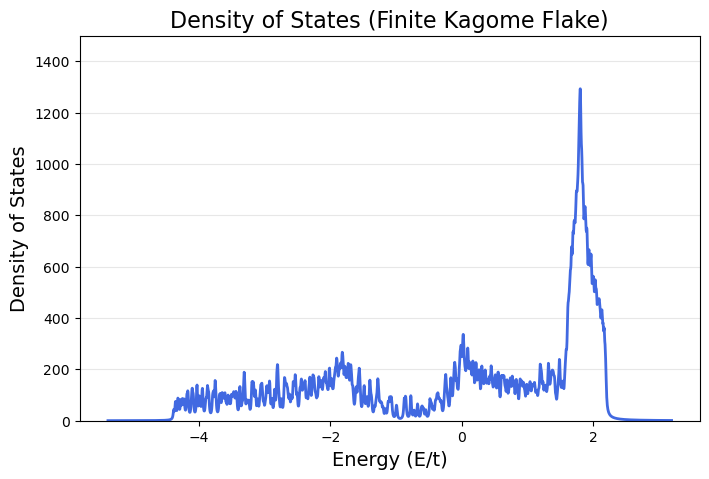

In [69]:

eigenvalues, eigenvectors = build_hamiltonian(BuildKagomeGrid(radius=20))
phi=np.abs(eigenvectors)**2
energies = np.real(eigenvalues)
delta=0.01
lodsEnergy=-2
ldos=delta/(np.pi*(delta**2+(energies-lodsEnergy)**2))
xaxis=np.sum(ldos*phi,axis=1)
range_E = np.linspace(np.min(energies)-1,np.max(energies)+1,2000)
dos = np.zeros_like(range_E)
for E in energies:
    dos += delta / (np.pi * (delta**2 + (range_E - E)**2))
min_E = np.min(eigenvalues)
max_E = np.max(eigenvalues)
plt.figure(figsize=(8, 5))
plt.plot(range_E, dos, color='royalblue', linewidth=2)

plt.title("Density of States (Finite Kagome Flake)", fontsize=16)
plt.xlabel("Energy (E/t)", fontsize=14)
plt.ylabel("Density of States", fontsize=14)


plt.ylim(0,1500)
plt.grid(axis='y', alpha=0.3)
plt.show()

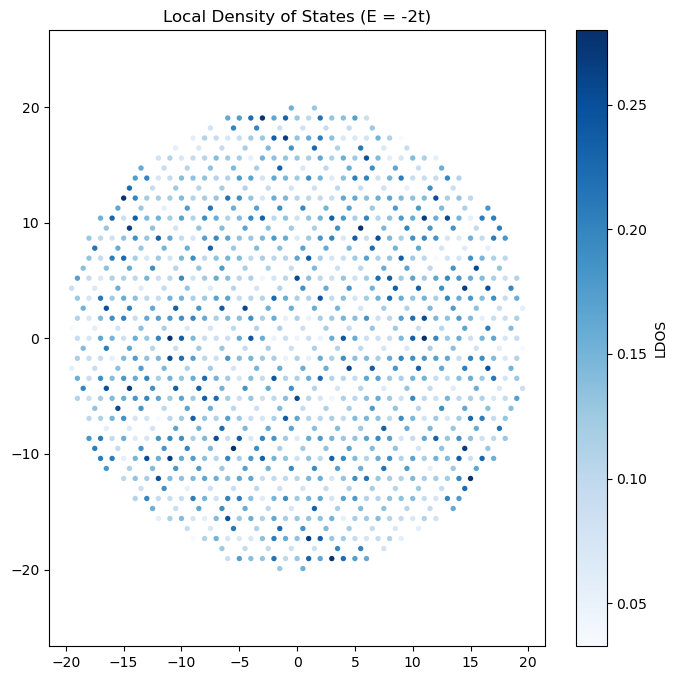

In [70]:
coordinates=np.array(BuildKagomeGrid(radius=20))
plt.figure(figsize=(8, 8))
plt.scatter(coordinates[:, 0], coordinates[:, 1], 
            c=xaxis, cmap='Blues', s=15, edgecolors='none')

plt.title(f"Local Density of States (E = {lodsEnergy}t)")
plt.axis('equal')
plt.colorbar(label="LDOS")
plt.show()
